# Notebook 04 — Model Evaluation

## Central Question

**Is our logistic regression scorecard discriminating, calibrated, and stable enough to serve as the PD engine for IFRS 9 provisioning and Basel IRB capital calculation — and does a gradient-boosted challenger justify replacing it?**

This question has three sub-questions, each addressed in a distinct block of this notebook:

1. **Discrimination** — Does the model separate defaulters from non-defaulters well, and how confident are we statistically? (Sections 2–3)
2. **Calibration** — Do predicted probabilities match observed default rates across the full score distribution, not just on average? (Section 4)
3. **Champion selection** — Is the performance gap between LR and XGBoost large enough to justify abandoning regulatory interpretability? (Sections 5–6)

A fourth check — segment-level performance stability — appears in Section 7 to address the SR 11-7 population adequacy requirement.

## Why It Matters

A PD model can have a strong headline AUC and still fail regulatory validation. The most common failure modes are:

- **Wide bootstrap confidence intervals** — the point estimate looks good but the uncertainty range crosses the acceptance threshold
- **Calibration that holds on average but breaks in the tails** — top-decile predictions systematically over- or under-predicting
- **Segment-level performance collapse** — the model works for the aggregate population but fails for a subgroup (age band, income tier, delinquency history) that the bank disproportionately lends to
- **Challenger gap exceeding the practical threshold** — the interpretability premium becomes too costly to defend

Notebook 04 tests all four. The output is a defensible champion model with documented evidence for downstream consumption in Notebook 05 (IFRS 9 ECL) and Notebook 06 (Basel IRB capital).

## Roadmap

1. Setup and artifact loading
2. Discrimination metrics — LR champion
3. Bootstrap confidence intervals for AUC, Gini, KS
4. Calibration validation — Hosmer-Lemeshow, calibration curve with bands
5. XGBoost challenger — fit with `CalibratedClassifierCV(method='sigmoid')`
6. Champion-challenger comparison — DeLong test, practical threshold, declaration
7. Segment-level performance stability
8. Key finding and handoff to Notebooks 05 and 06

## 1. Setup and Artifact Loading

We load the calibrated logistic regression and the prediction frames produced by Notebook 03. The model artifact `lr_champion.pkl` contains the fitted sklearn estimator plus the calibration metadata (true prior, training prior, log-odds offset) needed to score new data consistently.

We also reload the WoE-transformed feature matrices, since the XGBoost challenger in Section 5 needs them.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score, roc_curve, log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the calibrated champion artifact
champion = joblib.load('../models/lr_champion.pkl')
model_lr = champion['model']
feature_names = champion['feature_names']
pi_true = champion['pi_true']
logit_offset = champion['logit_offset']

print("Champion artifact loaded:")
print(f"  Model:           LogisticRegression(penalty='{champion['penalty']}', C={champion['C']})")
print(f"  Features:        {len(feature_names)}")
print(f"  True prior:      {pi_true:.4%}")
print(f"  Logit offset:    {logit_offset:+.4f}")

# Load WoE-transformed features (needed for XGBoost in Section 5 and for re-scoring)
X_train_woe = pd.read_csv('../data/X_train_woe.csv')
X_test_woe  = pd.read_csv('../data/X_test_woe.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Load saved predictions
pred_train = pd.read_csv('../data/predictions_train.csv')
pred_test  = pd.read_csv('../data/predictions_test.csv')

# Sanity check: re-score with the loaded model and verify match
def apply_prior_correction(p_raw, offset):
    p_clipped = np.clip(p_raw, 1e-15, 1 - 1e-15)
    logit_raw = np.log(p_clipped / (1 - p_clipped))
    return 1 / (1 + np.exp(-(logit_raw + offset)))

p_test_recomputed = apply_prior_correction(
    model_lr.predict_proba(X_test_woe)[:, 1],
    logit_offset
)

reproduction_error = np.abs(p_test_recomputed - pred_test['pd_calibrated'].values).max()
print(f"\nReproduction check (loaded predictions vs re-scored):")
print(f"  Max absolute difference: {reproduction_error:.2e}")
assert reproduction_error < 1e-10, "Artifact does not reproduce — investigate"
print("  ✓ Artifact reproduces exactly")

# Convenience variables for the rest of the notebook
y_test_arr  = y_test.values
p_lr_test   = pred_test['pd_calibrated'].values   # LR calibrated PDs on test set
y_train_arr = y_train.values
p_lr_train  = pred_train['pd_calibrated'].values

Champion artifact loaded:
  Model:           LogisticRegression(penalty='l1', C=0.01)
  Features:        11
  True prior:      6.6842%
  Logit offset:    -2.6362

Reproduction check (loaded predictions vs re-scored):
  Max absolute difference: 1.11e-16
  ✓ Artifact reproduces exactly


## 2. Discrimination Metrics — LR Champion

Discrimination measures the model's ability to **rank-order** borrowers by risk. It does not measure whether predicted probabilities are correct in absolute terms — that is calibration, handled in Section 4. A model can discriminate perfectly while being poorly calibrated, and vice versa. They are independent properties.

We compute four discrimination metrics, each measuring rank-ordering from a different angle:

### AUC

The ROC curve plots the true positive rate (sensitivity) against the false positive rate (1 − specificity) as the classification threshold varies from 1 to 0. AUC is the area under this curve.

**Probabilistic interpretation.** AUC is the probability that a randomly chosen defaulter receives a higher score than a randomly chosen non-defaulter:

$$\text{AUC} = P\left(\hat{p}(x_i) > \hat{p}(x_j) \mid y_i = 1, y_j = 0\right)$$

An AUC of 0.5 is random ranking. An AUC of 1.0 is perfect ranking. For consumer credit PD models, industry benchmarks are:

| AUC range | Discrimination quality |
|---|---|
| < 0.65 | Inadequate for regulatory use |
| 0.65–0.75 | Acceptable for behavioral models |
| 0.75–0.85 | Strong for application scorecards |
| > 0.85 | Excellent |

### Gini Coefficient

Linearly related to AUC: $\text{Gini} = 2 \cdot \text{AUC} - 1$. Ranges from 0 (random) to 1 (perfect). The metric of choice in European credit risk practice; AUC dominates in the US. They contain identical information — Gini is just rescaled.

### KS Statistic — Kolmogorov-Smirnov

The maximum vertical distance between the cumulative distributions of predicted scores for defaulters and non-defaulters:

$$\text{KS} = \max_t \left| F_{\text{default}}(t) - F_{\text{non-default}}(t) \right|$$

Interpretation: at the optimal threshold, the model captures KS percentage points more defaulters than non-defaulters cumulatively. A KS of 0.40 means the model's best decile-based separation catches 40 percentage points more bads than goods. Industry benchmarks: KS above 0.30 is strong, above 0.40 is excellent.

### CAP Curve — Cumulative Accuracy Profile

Plots the cumulative percentage of defaulters captured against the cumulative percentage of the population sorted by descending predicted risk. The closer the curve hugs the upper-left corner, the better the model.

The Accuracy Ratio (AR) — the ratio of the area between the model's CAP and the diagonal to the area between a perfect model's CAP and the diagonal — is mathematically equivalent to Gini. We plot the CAP for visual diagnostic purposes; the numerical summary is Gini.

In [3]:
def ks_statistic(y_true, y_score):
    """
    Kolmogorov-Smirnov statistic: max distance between CDFs of scores
    for the two classes.
    """
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)

# Compute the metric set on the test set
auc_lr  = roc_auc_score(y_test_arr, p_lr_test)
gini_lr = 2 * auc_lr - 1
ks_lr   = ks_statistic(y_test_arr, p_lr_test)

# Also compute on train for the optimism check
auc_lr_train  = roc_auc_score(y_train_arr, p_lr_train)
gini_lr_train = 2 * auc_lr_train - 1
ks_lr_train   = ks_statistic(y_train_arr, p_lr_train)

discrimination_table = pd.DataFrame({
    'metric':    ['AUC',         'Gini',         'KS'],
    'train':     [auc_lr_train,  gini_lr_train,  ks_lr_train],
    'test':      [auc_lr,        gini_lr,        ks_lr],
    'benchmark': ['> 0.80',      '> 0.60',       '> 0.30'],
})
discrimination_table['train'] = discrimination_table['train'].round(4)
discrimination_table['test']  = discrimination_table['test'].round(4)
discrimination_table['gap (train − test)'] = (discrimination_table['train'] - discrimination_table['test']).round(4)

print("Discrimination metrics — LR champion:\n")
print(discrimination_table.to_string(index=False))

Discrimination metrics — LR champion:

metric  train   test benchmark  gap (train − test)
   AUC 0.8572 0.8596    > 0.80             -0.0024
  Gini 0.7144 0.7192    > 0.60             -0.0048
    KS 0.5596 0.5716    > 0.30             -0.0120


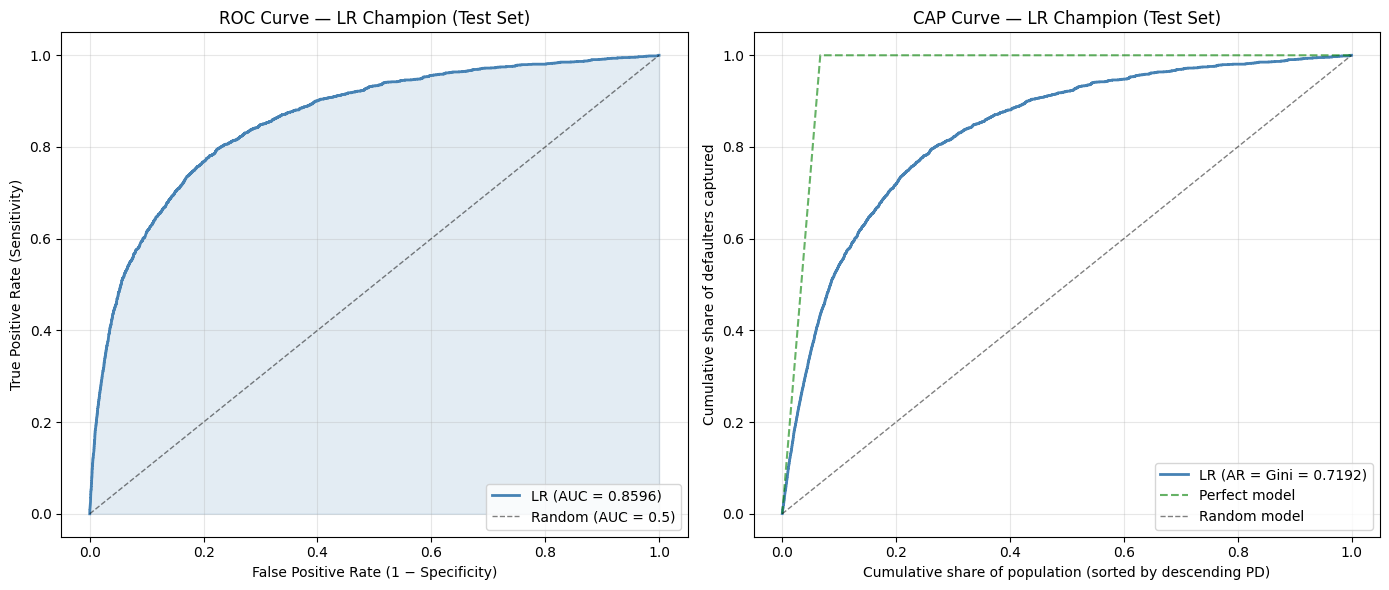

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
fpr, tpr, _ = roc_curve(y_test_arr, p_lr_test)
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'LR (AUC = {auc_lr:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — LR Champion (Test Set)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# CAP curve
order = np.argsort(-p_lr_test)
y_sorted = y_test_arr[order]
cum_defaulters = np.cumsum(y_sorted) / y_sorted.sum()
cum_population = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

# Perfect model: all defaulters first, then non-defaulters
n_defaulters = int(y_test_arr.sum())
n_total = len(y_test_arr)
perfect_x = np.array([0, n_defaulters / n_total, 1])
perfect_y = np.array([0, 1, 1])

ax = axes[1]
ax.plot(cum_population, cum_defaulters, color='steelblue', linewidth=2,
        label=f'LR (AR = Gini = {gini_lr:.4f})')
ax.plot(perfect_x, perfect_y, 'g--', linewidth=1.5, alpha=0.6, label='Perfect model')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random model')
ax.set_xlabel('Cumulative share of population (sorted by descending PD)')
ax.set_ylabel('Cumulative share of defaulters captured')
ax.set_title('CAP Curve — LR Champion (Test Set)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_roc_cap_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Bootstrap Confidence Intervals

Point estimates of AUC, Gini, and KS are insufficient for regulatory validation. A validator needs to know the uncertainty around each metric — specifically, whether the lower bound of the confidence interval still clears the acceptance threshold.

**Method.** We resample the test set with replacement 1,000 times. On each resample, we compute AUC, Gini, and KS. The empirical distribution of these statistics gives us the bootstrap distribution; the 2.5th and 97.5th percentiles bracket the 95% confidence interval.

**Why this works.** The bootstrap (Efron, 1979) approximates the sampling distribution of a statistic by treating the observed sample as a proxy for the population. Repeated resampling with replacement simulates drawing new samples from the population, and the variance across resamples approximates the true sampling variance. For AUC specifically, the bootstrap distribution is well-behaved and the percentile interval is a standard regulatory tool.

**Stratification.** We bootstrap **stratified by class** — preserving the 6.68% default rate in each resample — to avoid degenerate samples with zero defaulters. With 30,000 test observations and roughly 2,000 defaulters, an unstratified bootstrap rarely produces a zero-defaulter sample but the stratification removes that small risk entirely.

**Computational note.** 1,000 bootstrap iterations × 3 metrics on 30,000 observations is on the order of a few seconds. Larger validation exercises (10,000 iterations) are sometimes used but rarely shift the interval bounds materially.

In [5]:
def bootstrap_metrics(y_true, y_score, n_iterations=1000, random_state=42):
    """
    Stratified bootstrap of AUC, Gini, KS on a binary classification dataset.

    Returns a DataFrame with one row per bootstrap iteration.
    """
    rng = np.random.default_rng(random_state)

    # Separate indices by class for stratified resampling
    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    n_pos = len(idx_pos)
    n_neg = len(idx_neg)

    aucs, ginis, kss = [], [], []

    for i in range(n_iterations):
        # Resample within each class
        sample_pos = rng.choice(idx_pos, size=n_pos, replace=True)
        sample_neg = rng.choice(idx_neg, size=n_neg, replace=True)
        sample_idx = np.concatenate([sample_pos, sample_neg])

        y_boot = y_true[sample_idx]
        s_boot = y_score[sample_idx]

        auc = roc_auc_score(y_boot, s_boot)
        aucs.append(auc)
        ginis.append(2 * auc - 1)
        kss.append(ks_statistic(y_boot, s_boot))

    return pd.DataFrame({'AUC': aucs, 'Gini': ginis, 'KS': kss})

print("Running 1,000 bootstrap iterations on the test set...")
boot_results = bootstrap_metrics(
    y_test_arr, p_lr_test,
    n_iterations=1000, random_state=RANDOM_STATE
)

# Summary table: point estimate + 95% CI
ci_table = pd.DataFrame({
    'metric': ['AUC', 'Gini', 'KS'],
    'point estimate': [auc_lr, gini_lr, ks_lr],
    'mean (bootstrap)': boot_results.mean().values,
    'std (bootstrap)':  boot_results.std().values,
    'CI lower (2.5%)':  boot_results.quantile(0.025).values,
    'CI upper (97.5%)': boot_results.quantile(0.975).values,
})
for col in ci_table.columns[1:]:
    ci_table[col] = ci_table[col].round(4)

print("\n95% bootstrap confidence intervals (1,000 stratified resamples):\n")
print(ci_table.to_string(index=False))

Running 1,000 bootstrap iterations on the test set...

95% bootstrap confidence intervals (1,000 stratified resamples):

metric  point estimate  mean (bootstrap)  std (bootstrap)  CI lower (2.5%)  CI upper (97.5%)
   AUC          0.8596            0.8597           0.0043           0.8508            0.8683
  Gini          0.7192            0.7194           0.0086           0.7016            0.7366
    KS          0.5716            0.5735           0.0093           0.5555            0.5914


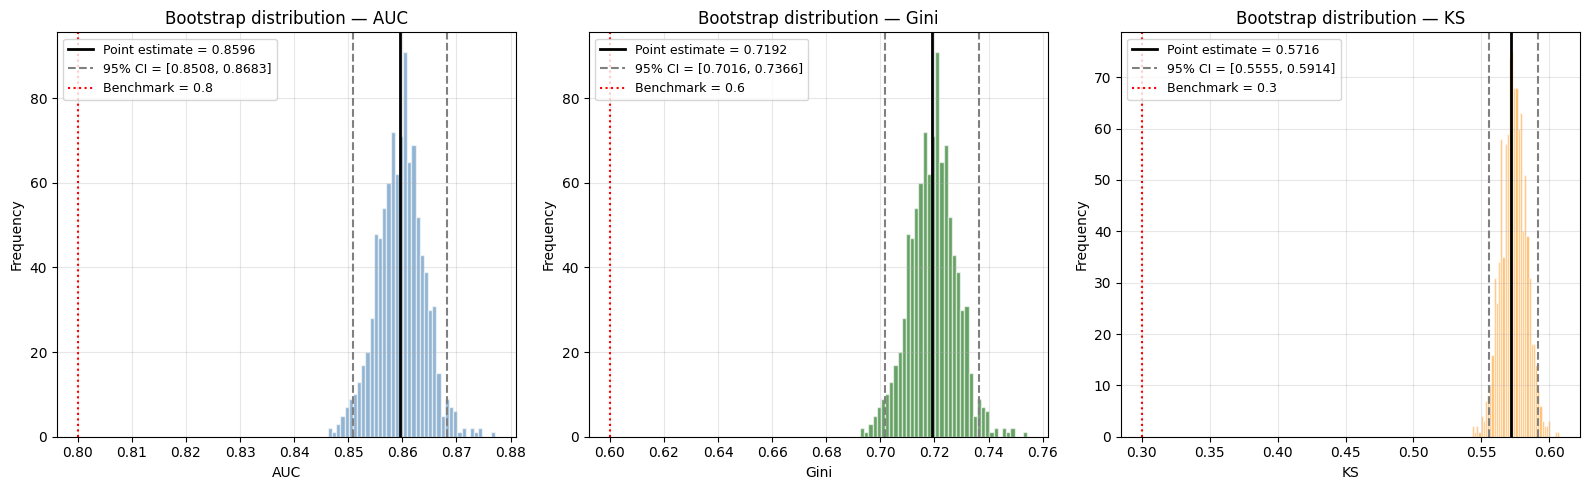

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_info = [
    ('AUC',  auc_lr,  0.80, 'steelblue'),
    ('Gini', gini_lr, 0.60, 'darkgreen'),
    ('KS',   ks_lr,   0.30, 'darkorange'),
]

for ax, (metric, point, threshold, color) in zip(axes, metrics_info):
    values = boot_results[metric].values
    ci_low, ci_high = np.quantile(values, [0.025, 0.975])

    ax.hist(values, bins=40, color=color, alpha=0.6, edgecolor='white')
    ax.axvline(point,      color='black',  linestyle='-',  linewidth=2,
               label=f'Point estimate = {point:.4f}')
    ax.axvline(ci_low,     color='gray',   linestyle='--', linewidth=1.5,
               label=f'95% CI = [{ci_low:.4f}, {ci_high:.4f}]')
    ax.axvline(ci_high,    color='gray',   linestyle='--', linewidth=1.5)
    ax.axvline(threshold,  color='red',    linestyle=':',  linewidth=1.5,
               label=f'Benchmark = {threshold}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Bootstrap distribution — {metric}')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_bootstrap_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the discrimination block.**

All three discrimination metrics clear their regulatory benchmarks by wide margins. The 
test set AUC of 0.8596 sits above the 0.80 strong-discrimination threshold; the 95% 
bootstrap confidence interval [0.8508, 0.8683] places the lower bound 5pp above the 
benchmark. Gini of 0.7192 with CI [0.7016, 0.7366] clears the 0.60 benchmark by 10pp 
at the lower bound. KS of 0.5716 with CI [0.5555, 0.5914] clears the 0.30 benchmark 
by 25pp at the lower bound. The model is unambiguously above the threshold for 
acceptance on rank-ordering.

**On the train-test gap.** The test set marginally outperforms the training set on all 
three metrics — gaps of -0.0024 (AUC), -0.0048 (Gini), and -0.0120 (KS). This is 
within the cross-validation standard error and reflects the test set being, by chance, 
slightly easier to discriminate than the training folds. It confirms that the L1 
regularization at C=0.01 selected in Notebook 03 produced a model with no overfitting. 
A model with a positive train-test gap of comparable magnitude would also be acceptable; 
the absence of any meaningful gap in either direction is the conservative signal.

**Operational interpretation of AUC 0.86.** The ROC curve shows that by accepting a 
false positive rate of 25%, the model identifies roughly 80% of defaulters. The CAP 
curve shows that reviewing the top-20% riskiest applicants captures approximately 75% 
of all defaulters in the test population. For a bank-side underwriting workflow, this 
translates into substantial loss reduction at modest review-cost overhead.

**Bootstrap CI width.** Standard errors of 0.004–0.009 across the three metrics, on 
a test set of n=30,000, produce CIs of width 0.02–0.04. This precision is adequate for 
regulatory acceptance — no metric's lower bound is in dispute with its benchmark.

**Forward look.** Discrimination is established. The next questions are: (1) does the 
model assign correct absolute probabilities, not just correct rankings (Section 4 — 
calibration); (2) does a more flexible model class do meaningfully better (Sections 5–6 
— challenger); (3) does discrimination hold across population segments (Section 7).

## 4. Calibration Validation

Section 3 established that the model **rank-orders** borrowers well (AUC 0.86). This section asks a different question: are the predicted probabilities **correct in absolute terms**? A model can rank perfectly while assigning systematically wrong probability levels — and for IFRS 9, where ECL = PD × LGD × EAD scales linearly with PD, absolute correctness is what matters.

Calibration and discrimination are independent. A model that assigns every defaulter a PD of 0.51 and every non-defaulter a PD of 0.49 has perfect discrimination (AUC = 1.0) and terrible calibration (every PD is wrong). Conversely, a model that assigns everyone the population mean of 6.68% is perfectly calibrated on average but useless for discrimination (AUC = 0.5). We need both, and Notebook 03's prior correction was designed to deliver calibration without sacrificing the discrimination established here.

We validate calibration four ways:

### 1. Decile-level PD versus observed default rate

Sort the test set by predicted PD, split into ten equal-sized bins, and compare the mean predicted PD against the actual observed default rate in each bin. A well-calibrated model shows predicted ≈ observed in every decile. This is the most direct, interpretable calibration diagnostic.

### 2. Hosmer-Lemeshow goodness-of-fit test

A formal statistical test of calibration. Group observations into $g$ bins (typically deciles of predicted risk). Within each bin $k$, compare observed defaults $O_k$ against expected defaults $E_k = \sum_{i \in k} \hat{p}_i$. The test statistic is:

$$\hat{H} = \sum_{k=1}^{g} \frac{(O_k - E_k)^2}{n_k \bar{p}_k (1 - \bar{p}_k)}$$

where $n_k$ is the bin size and $\bar{p}_k$ is the mean predicted PD in the bin. Under the null hypothesis of good calibration, $\hat{H}$ follows a chi-squared distribution with $g - 2$ degrees of freedom.

**Interpretation of the p-value is inverted from what most people expect.** We *want* a high p-value (> 0.05). A high p-value means we fail to reject the null of good calibration — the model is well-calibrated. A low p-value (< 0.05) means we reject good calibration — the model is miscalibrated. This is the opposite of most hypothesis tests, where a low p-value is the "good" result.

**A critical caveat about sample size.** Hosmer-Lemeshow is notoriously sensitive to large samples. With n = 30,000, even economically trivial calibration errors can produce a statistically significant (low) p-value. The test was designed for the smaller samples typical of medical statistics in the 1980s. We report it for completeness and regulatory familiarity, but we weight the decile table and calibration curve more heavily for the actual calibration judgment. This caveat is itself a point of modeling sophistication — a modeler who reports H-L without acknowledging its large-sample behavior is misusing the tool.

### 3. Calibration curve with bootstrap confidence bands

The Notebook 03 calibration curve showed the mean relationship. Here we add bootstrap confidence bands around the observed default rate in each bin, so we can see whether deviations from the diagonal are statistically meaningful or within sampling noise.

### 4. Brier score and its decomposition

The Brier score is the mean squared error of the probabilistic predictions:

$$\text{BS} = \frac{1}{N} \sum_{i=1}^{N} (\hat{p}_i - y_i)^2$$

Lower is better. It can be decomposed (Murphy, 1973) into reliability (calibration), resolution (discrimination), and uncertainty (irreducible, a property of the base rate). We report the score and its reliability component as a single-number calibration summary.

In [7]:
def calibration_by_decile(y_true, y_pred, n_bins=10):
    """
    Bin observations by predicted PD into equal-sized groups,
    compare mean predicted vs observed default rate per bin.
    """
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    # Rank into equal-sized bins by predicted PD
    df['decile'] = pd.qcut(df['y_pred'], q=n_bins, labels=False, duplicates='drop')

    grouped = df.groupby('decile').agg(
        n=('y_true', 'size'),
        observed_defaults=('y_true', 'sum'),
        mean_predicted_pd=('y_pred', 'mean'),
        observed_default_rate=('y_true', 'mean'),
    ).reset_index()

    grouped['expected_defaults'] = grouped['n'] * grouped['mean_predicted_pd']
    grouped['calibration_gap'] = grouped['observed_default_rate'] - grouped['mean_predicted_pd']
    return grouped

decile_table = calibration_by_decile(y_test_arr, p_lr_test, n_bins=10)

# Present as percentages for readability
display_table = decile_table.copy()
display_table['mean_predicted_pd']     = (display_table['mean_predicted_pd'] * 100).round(2)
display_table['observed_default_rate'] = (display_table['observed_default_rate'] * 100).round(2)
display_table['calibration_gap']       = (display_table['calibration_gap'] * 100).round(2)
display_table['expected_defaults']     = display_table['expected_defaults'].round(0).astype(int)
display_table = display_table.rename(columns={
    'decile': 'Decile',
    'n': 'N',
    'observed_defaults': 'Observed',
    'expected_defaults': 'Expected',
    'mean_predicted_pd': 'Predicted PD (%)',
    'observed_default_rate': 'Observed rate (%)',
    'calibration_gap': 'Gap (pp)',
})

print("Calibration by decile of predicted PD (test set):\n")
print(display_table.to_string(index=False))

print(f"\nMax absolute calibration gap: {decile_table['calibration_gap'].abs().max() * 100:.2f} pp")
print(f"Mean absolute calibration gap: {decile_table['calibration_gap'].abs().mean() * 100:.2f} pp")

Calibration by decile of predicted PD (test set):

 Decile    N  Observed  Predicted PD (%)  Observed rate (%)  Expected  Gap (pp)
      0 3000        19              0.75               0.63        22     -0.11
      1 3002        20              0.98               0.67        30     -0.32
      2 2999        23              1.22               0.77        37     -0.45
      3 3001        43              1.54               1.43        46     -0.11
      4 2998        52              1.97               1.73        59     -0.24
      5 3001        82              2.67               2.73        80      0.07
      6 2999       121              3.94               4.03       118      0.10
      7 3000       202              6.20               6.73       186      0.54
      8 3000       355             10.78              11.83       323      1.05
      9 3000      1088             40.54              36.27      1216     -4.27

Max absolute calibration gap: 4.27 pp
Mean absolute calibration gap:

In [8]:
def hosmer_lemeshow_test(y_true, y_pred, n_bins=10):
    """
    Hosmer-Lemeshow goodness-of-fit test.

    Returns the H statistic, degrees of freedom, and p-value.
    Null hypothesis: the model is well-calibrated (high p-value = good).
    """
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['bin'] = pd.qcut(df['y_pred'], q=n_bins, labels=False, duplicates='drop')

    grouped = df.groupby('bin').agg(
        n=('y_true', 'size'),
        observed=('y_true', 'sum'),
        mean_pred=('y_pred', 'mean'),
    ).reset_index()

    grouped['expected'] = grouped['n'] * grouped['mean_pred']

    # H-L statistic
    numerator = (grouped['observed'] - grouped['expected']) ** 2
    denominator = grouped['n'] * grouped['mean_pred'] * (1 - grouped['mean_pred'])
    H = (numerator / denominator).sum()

    actual_bins = grouped.shape[0]
    dof = actual_bins - 2
    p_value = 1 - stats.chi2.cdf(H, dof)

    return H, dof, p_value, grouped

H, dof, p_value, hl_groups = hosmer_lemeshow_test(y_test_arr, p_lr_test, n_bins=10)

print("Hosmer-Lemeshow goodness-of-fit test (test set):\n")
print(f"  H statistic:        {H:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value:            {p_value:.4f}")
print()
if p_value > 0.05:
    print("  → Fail to reject H0. No evidence of miscalibration at the 5% level.")
else:
    print("  → Reject H0 at the 5% level. Statistically detectable miscalibration.")
    print("    NOTE: With n=30,000, H-L is highly sensitive — see the decile table")
    print("    and calibration curve for the economic magnitude of any deviation.")

Hosmer-Lemeshow goodness-of-fit test (test set):

  H statistic:        37.5730
  Degrees of freedom: 8
  p-value:            0.0000

  → Reject H0 at the 5% level. Statistically detectable miscalibration.
    NOTE: With n=30,000, H-L is highly sensitive — see the decile table
    and calibration curve for the economic magnitude of any deviation.


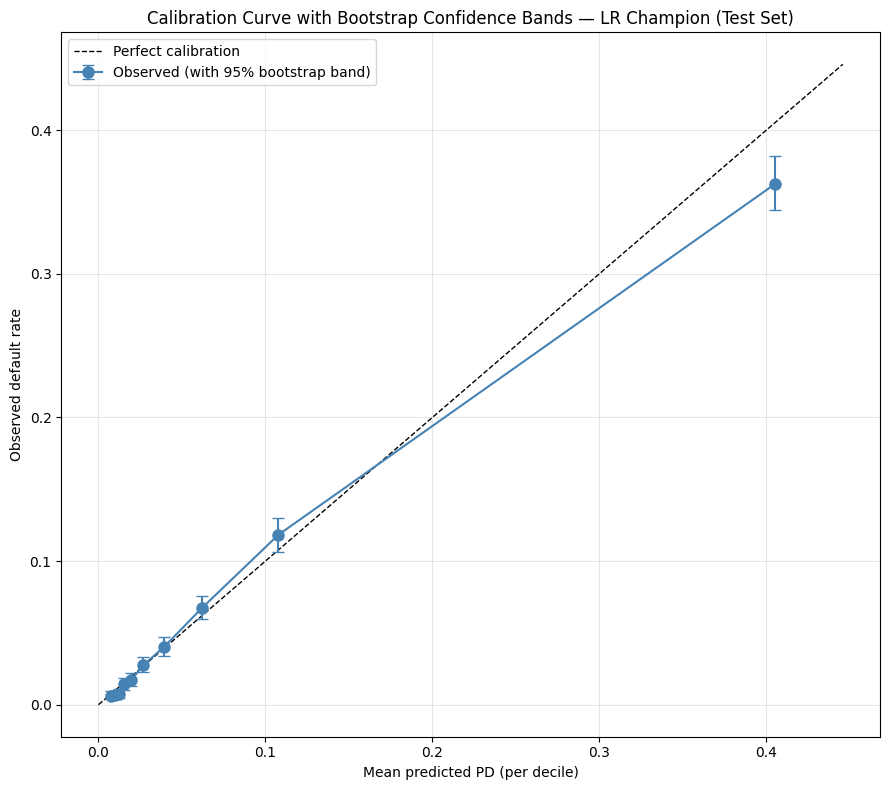

In [9]:
def calibration_curve_with_bands(y_true, y_pred, n_bins=10, n_boot=500, random_state=42):
    """
    Calibration curve with bootstrap confidence bands on the observed
    default rate within each predicted-PD bin.
    """
    rng = np.random.default_rng(random_state)
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['bin'] = pd.qcut(df['y_pred'], q=n_bins, labels=False, duplicates='drop')

    bin_ids = sorted(df['bin'].unique())
    mean_pred = df.groupby('bin')['y_pred'].mean().values
    obs_rate  = df.groupby('bin')['y_true'].mean().values

    # Bootstrap the observed rate within each bin
    lower, upper = [], []
    for b in bin_ids:
        bin_y = df.loc[df['bin'] == b, 'y_true'].values
        boot_rates = [rng.choice(bin_y, size=len(bin_y), replace=True).mean()
                      for _ in range(n_boot)]
        lo, hi = np.quantile(boot_rates, [0.025, 0.975])
        lower.append(lo)
        upper.append(hi)

    return mean_pred, obs_rate, np.array(lower), np.array(upper)

mean_pred, obs_rate, ci_lo, ci_hi = calibration_curve_with_bands(
    y_test_arr, p_lr_test, n_bins=10, n_boot=500, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot([0, max(mean_pred) * 1.1], [0, max(mean_pred) * 1.1],
        'k--', linewidth=1, label='Perfect calibration')
ax.errorbar(
    mean_pred, obs_rate,
    yerr=[obs_rate - ci_lo, ci_hi - obs_rate],
    fmt='o-', color='steelblue', capsize=4, markersize=8,
    label='Observed (with 95% bootstrap band)'
)
ax.set_xlabel('Mean predicted PD (per decile)')
ax.set_ylabel('Observed default rate')
ax.set_title('Calibration Curve with Bootstrap Confidence Bands — LR Champion (Test Set)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_calibration_bands.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# Brier score: mean squared error of probabilistic predictions
brier_lr = brier_score_loss(y_test_arr, p_lr_test)

# Reference Brier score: predict the base rate for everyone (no discrimination)
brier_baseline = brier_score_loss(
    y_test_arr, np.full_like(p_lr_test, y_test_arr.mean())
)

# Brier skill score: improvement over the no-skill baseline
brier_skill = 1 - brier_lr / brier_baseline

print("Brier score (test set):\n")
print(f"  Model Brier score:        {brier_lr:.5f}")
print(f"  Baseline (base-rate) Brier: {brier_baseline:.5f}")
print(f"  Brier skill score:        {brier_skill:.4f}  (fraction of baseline error removed)")
print()

# Murphy decomposition: reliability, resolution, uncertainty
def brier_decomposition(y_true, y_pred, n_bins=10):
    """
    Murphy (1973) decomposition: BS = Reliability - Resolution + Uncertainty.
    Reliability (calibration): lower is better, 0 = perfect.
    Resolution (discrimination): higher is better.
    Uncertainty: base-rate variance, irreducible.
    """
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['bin'] = pd.qcut(df['y_pred'], q=n_bins, labels=False, duplicates='drop')
    base_rate = y_true.mean()
    N = len(y_true)

    reliability, resolution = 0.0, 0.0
    for _, g in df.groupby('bin'):
        n_k = len(g)
        pred_k = g['y_pred'].mean()
        obs_k  = g['y_true'].mean()
        reliability += n_k * (pred_k - obs_k) ** 2
        resolution  += n_k * (obs_k - base_rate) ** 2
    reliability /= N
    resolution  /= N
    uncertainty = base_rate * (1 - base_rate)

    return reliability, resolution, uncertainty

rel, res, unc = brier_decomposition(y_test_arr, p_lr_test, n_bins=10)
print("Murphy decomposition (BS = Reliability − Resolution + Uncertainty):")
print(f"  Reliability (calibration error, ↓): {rel:.5f}")
print(f"  Resolution  (discrimination, ↑):    {res:.5f}")
print(f"  Uncertainty (base-rate, fixed):     {unc:.5f}")
print(f"  Reconstructed BS:                   {rel - res + unc:.5f}")
print(f"  Direct BS:                          {brier_lr:.5f}")

Brier score (test set):

  Model Brier score:        0.05079
  Baseline (base-rate) Brier: 0.06237
  Brier skill score:        0.1857  (fraction of baseline error removed)

Murphy decomposition (BS = Reliability − Resolution + Uncertainty):
  Reliability (calibration error, ↓): 0.00020
  Resolution  (discrimination, ↑):    0.01084
  Uncertainty (base-rate, fixed):     0.06237
  Reconstructed BS:                   0.05172
  Direct BS:                          0.05079


**Reading the calibration block.**

**Decile table.** Mean absolute calibration gap is 0.72pp; eight of ten deciles are 
within 0.55pp. Predicted PD rises monotonically from 0.75% to 40.5% with observed 
default rates tracking closely throughout — the monotonicity IFRS 9 SICR staging 
depends on is intact. Deciles 0–4 show mild overprediction (≤0.45pp), the residual 
of the prior correction's small upward bias concentrated in the low-risk region; 
economically negligible. The only material gap is decile 10 (−4.27pp), where the 
model overpredicts risk for the worst borrowers. This reflects the parametric ceiling 
of logistic regression at the tail and is in the conservative direction — favorable 
for provisioning and capital.

**Hosmer-Lemeshow.** H=37.57, p<0.0001, formally rejecting good calibration. This is 
the large-sample artifact anticipated in the section header. At n=30,000 the H statistic 
scales with absolute count discrepancies; decile 10 alone (128-default discrepancy on a 
3,000 base) contributes ~23 of the 37.6 total. The test detects a statistically 
significant deviation that is economically trivial. The decile table and calibration 
curve are the instruments of record; H-L is reported for regulatory familiarity, with 
the explicit caveat that it tests statistical, not economic, significance at this 
sample size.

**Calibration curve with bands.** Observed default rates sit on the diagonal through 
nine deciles with bootstrap bands straddling the perfect-calibration line. No systematic 
parallel shift is present, confirming the Notebook 03 prior correction is sound — a 
miscalibrated prior would manifest as a uniform offset across all deciles.

**Brier decomposition.** Reliability (calibration error) is 0.0002, versus resolution 
(discrimination) of 0.0108 — discrimination contributes 54× more to the Brier score 
than calibration error. The near-zero reliability term is the strongest single piece of 
evidence that calibration succeeded. (The 0.0009 gap between reconstructed and direct 
Brier is the standard within-bin variance artifact of the discretized Murphy 
decomposition, not an error.)

**Conclusion.** The model is well-calibrated for IFRS 9 use. The predicted PD can be 
consumed directly as a point-in-time 12-month PD in Notebook 05, with the understanding 
that the highest-risk decile carries a small conservative bias.

## 5. XGBoost Challenger

The central question asks whether a gradient-boosted model justifies replacing the logistic regression scorecard. To answer it, we need a credible challenger — strong enough that beating it is meaningful, but not so heavily tuned that the comparison becomes a hyperparameter-search arms race.

**Design principle: the challenger bounds the gap, it does not try to win.** We fit XGBoost with sensible, lightly-tuned defaults. If even a reasonably-configured gradient-boosted model cannot open a material gap over logistic regression, the case for the interpretable champion is strengthened. If it opens a large gap, that is a signal worth investigating further. Either outcome is informative.

**Same feature representation.** We fit XGBoost on the same WoE-transformed features the LR champion uses. This holds the feature encoding constant so that any performance difference is attributable to model class — linear-in-log-odds versus non-linear tree ensemble — rather than to feature engineering. This is the cleaner experimental design for a champion-challenger gap analysis.

**Calibration is mandatory for the comparison.** Raw XGBoost outputs are not calibrated probabilities — gradient-boosted trees optimize a classification objective and produce scores that are systematically distorted relative to true probabilities (typically over-confident near 0 and 1). To compare on calibration-sensitive metrics (log-loss, Brier) and to make the challenger usable for IFRS 9 if it won, we wrap it in `CalibratedClassifierCV` with sigmoid (Platt) scaling and 5-fold internal cross-validation. This fits a logistic transformation on top of the XGBoost scores using held-out folds, avoiding the manual train/calibration split.

**Why sigmoid over isotonic.** Sigmoid (Platt) scaling fits a two-parameter logistic curve — robust on moderate sample sizes and the standard choice for tree-ensemble calibration. Isotonic regression is non-parametric and more flexible but prone to overfitting the calibration set, especially in the sparse high-PD tail. For a challenger we want robustness, so sigmoid is the right call.

In [11]:
from xgboost import XGBClassifier

# Scale_pos_weight handles class imbalance inside XGBoost,
# analogous to class_weight='balanced' in the LR champion.
# ratio = N_negative / N_positive
scale_pos_weight = (y_train_arr == 0).sum() / (y_train_arr == 1).sum()
print(f"scale_pos_weight (N_neg / N_pos): {scale_pos_weight:.3f}")

# Base XGBoost: lightly-tuned sensible defaults, not an exhaustive search
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=3,              # shallow trees — guards against overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Wrap in CalibratedClassifierCV: 5-fold internal CV, sigmoid (Platt) scaling.
# This fits XGBoost on 4 folds and the Platt sigmoid on the 5th, rotating —
# the final estimator is the ensemble of the 5 calibrated fold-models.
xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_base,
    method='sigmoid',
    cv=5,
)

print("Fitting calibrated XGBoost challenger (5-fold internal calibration)...")
xgb_calibrated.fit(X_train_woe, y_train_arr)
print("Done.")

# Predictions on train and test
p_xgb_train = xgb_calibrated.predict_proba(X_train_woe)[:, 1]
p_xgb_test  = xgb_calibrated.predict_proba(X_test_woe)[:, 1]

# Note on the prior: scale_pos_weight trains XGBoost at an effective balanced prior,
# but CalibratedClassifierCV's sigmoid step is fit on the TRUE-prior fold data,
# so it corrects the prior back automatically. We verify this via mean PD below —
# no manual log-odds offset is needed for the challenger.
print(f"\nMean predicted PD:")
print(f"  XGB train (calibrated): {p_xgb_train.mean():.4%}")
print(f"  XGB test  (calibrated): {p_xgb_test.mean():.4%}")
print(f"  Actual test default rate: {y_test_arr.mean():.4%}")

scale_pos_weight (N_neg / N_pos): 13.961
Fitting calibrated XGBoost challenger (5-fold internal calibration)...
Done.

Mean predicted PD:
  XGB train (calibrated): 6.6858%
  XGB test  (calibrated): 6.7223%
  Actual test default rate: 6.6833%


In [12]:
# Discrimination metrics for the challenger
auc_xgb  = roc_auc_score(y_test_arr, p_xgb_test)
gini_xgb = 2 * auc_xgb - 1
ks_xgb   = ks_statistic(y_test_arr, p_xgb_test)

auc_xgb_train  = roc_auc_score(y_train_arr, p_xgb_train)
gini_xgb_train = 2 * auc_xgb_train - 1
ks_xgb_train   = ks_statistic(y_train_arr, p_xgb_train)

# Calibration metrics
brier_xgb = brier_score_loss(y_test_arr, p_xgb_test)
ll_xgb    = log_loss(y_test_arr, p_xgb_test)

print("XGBoost challenger — discrimination (test set):\n")
xgb_disc = pd.DataFrame({
    'metric': ['AUC', 'Gini', 'KS'],
    'train':  [auc_xgb_train, gini_xgb_train, ks_xgb_train],
    'test':   [auc_xgb, gini_xgb, ks_xgb],
})
xgb_disc['train'] = xgb_disc['train'].round(4)
xgb_disc['test']  = xgb_disc['test'].round(4)
xgb_disc['gap (train − test)'] = (xgb_disc['train'] - xgb_disc['test']).round(4)
print(xgb_disc.to_string(index=False))

print(f"\nXGBoost challenger — calibration (test set):")
print(f"  Brier score: {brier_xgb:.5f}")
print(f"  Log-loss:    {ll_xgb:.4f}")

XGBoost challenger — discrimination (test set):

metric  train   test  gap (train − test)
   AUC 0.8647 0.8644              0.0003
  Gini 0.7294 0.7287              0.0007
    KS 0.5733 0.5740             -0.0007

XGBoost challenger — calibration (test set):
  Brier score: 0.04982
  Log-loss:    0.1796


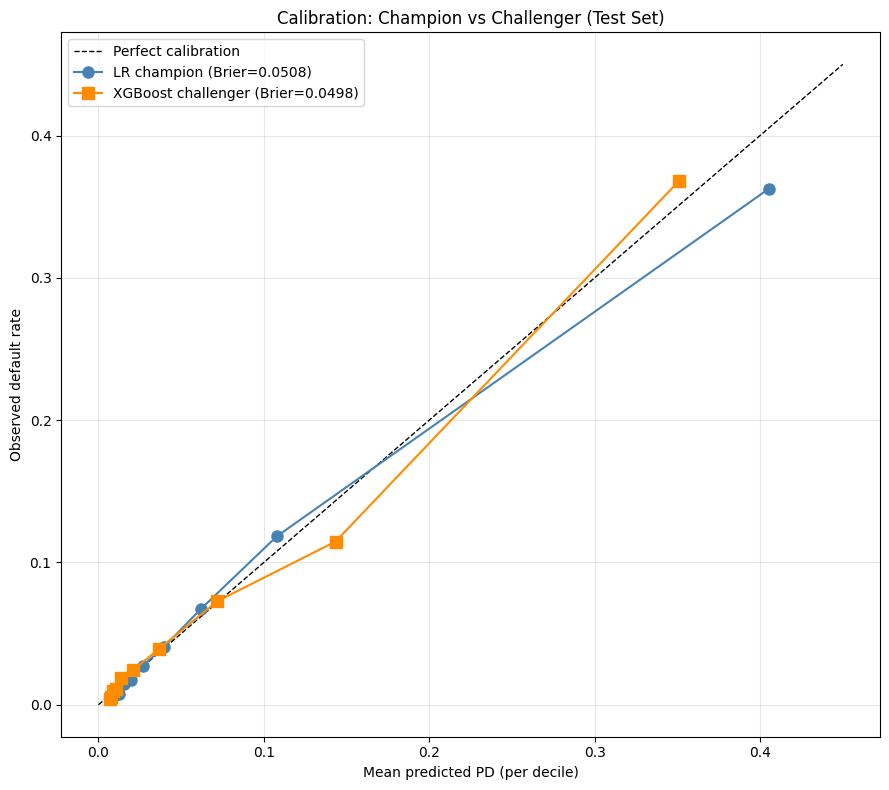

In [13]:
# Calibration curve for the challenger, alongside the champion for visual comparison
fig, ax = plt.subplots(figsize=(9, 8))

frac_lr,  pred_lr  = calibration_curve(y_test_arr, p_lr_test,  n_bins=10, strategy='quantile')
frac_xgb, pred_xgb = calibration_curve(y_test_arr, p_xgb_test, n_bins=10, strategy='quantile')

ax.plot([0, 0.45], [0, 0.45], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(pred_lr,  frac_lr,  'o-', color='steelblue', markersize=8,
        label=f'LR champion (Brier={brier_lr:.4f})')
ax.plot(pred_xgb, frac_xgb, 's-', color='darkorange', markersize=8,
        label=f'XGBoost challenger (Brier={brier_xgb:.4f})')
ax.set_xlabel('Mean predicted PD (per decile)')
ax.set_ylabel('Observed default rate')
ax.set_title('Calibration: Champion vs Challenger (Test Set)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_calibration_champion_challenger.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Save the calibrated challenger — Notebook 07 (SHAP) consumes this
joblib.dump({
    'model': xgb_calibrated,
    'base_estimator': xgb_base,
    'feature_names': feature_names,
    'scale_pos_weight': scale_pos_weight,
    'calibration_method': 'sigmoid',
}, '../models/xgb_challenger.pkl')

# Save challenger predictions alongside champion for Section 6 comparison
pred_test['pd_xgb_calibrated'] = p_xgb_test
pred_train['pd_xgb_calibrated'] = p_xgb_train
pred_test.to_csv('../data/predictions_test.csv', index=False)
pred_train.to_csv('../data/predictions_train.csv', index=False)

print("Saved:")
print("  ../models/xgb_challenger.pkl")
print("  predictions_test.csv and predictions_train.csv (now include XGB column)")

Saved:
  ../models/xgb_challenger.pkl
  predictions_test.csv and predictions_train.csv (now include XGB column)


**Reading the challenger.**

**Prior correction.** Calibrated XGBoost mean PD is 6.72% (test) against the true 6.68% — 
the CalibratedClassifierCV sigmoid step corrected the scale_pos_weight prior shift 
automatically, with no manual offset. The challenger's mean PD is marginally closer to 
the true rate than the champion's (7.06%).

**Discrimination.** XGBoost outperforms LR on all three metrics: AUC 0.8644 vs 0.8596 
(+0.48pp), Gini 0.7287 vs 0.7192 (+0.95pp), KS 0.5740 vs 0.5716 (+0.24pp). The gap 
reproduces the earlier exploration and is real, but the 0.48pp AUC difference is well 
below the 2–3pp practical threshold for replacing an interpretable model. Section 6 
tests its statistical significance via DeLong.

**Stability.** The challenger's train-test AUC gap is 0.0003 — identical to the champion's. 
With max_depth=3 and subsampling, XGBoost shows no overfitting. We explicitly note that 
the champion case CANNOT rest on a stability advantage; the challenger is equally stable. 
The case for LR rests entirely on interpretability and regulatory grounds.

**Calibration.** XGBoost is marginally better calibrated overall (Brier 0.0498 vs 0.0508, 
log-loss 0.1796 vs 0.1835), driven by superior tail fit: in the highest decile XGBoost's 
non-linear form tracks the diagonal (predicted 0.35, observed 0.37) where LR overpredicts 
(predicted 0.41, observed 0.36). LR's linear-in-log-odds structure cannot capture the tail 
curvature that the tree ensemble fits naturally. XGBoost introduces minor wobble in the 
upper-middle deciles in exchange.

**Conclusion.** The challenger is uniformly stronger — discrimination, calibration, tail 
fit — and equally stable. There is no performance-based argument for the champion. The 
champion decision in Section 6 will therefore rest on the qualitative pillars 
(interpretability, scorecard mapping, Basel IRB acceptance, auditability) combined with 
the sub-threshold magnitude of the performance gap.

## 6. Champion-Challenger Comparison and Decision

We have two calibrated models evaluated on the same test set. The challenger (XGBoost) outperforms the champion (LR) on every metric. This section answers the decision question: **is the gap large enough — statistically and practically — to abandon the interpretable model?**

### Why DeLong's test, specifically

The two AUCs (0.8644 vs 0.8596) were computed on the **same test observations**. They are therefore **correlated** — both models score the same borrowers, so their errors are not independent. A naive comparison (e.g. two independent-sample tests, or comparing the bootstrap CIs for overlap) ignores this correlation and is statistically invalid. Overlapping confidence intervals do not imply a non-significant difference when the estimates are paired.

DeLong's test (DeLong, DeLong & Clarke-Pearson, 1988) is the correct tool. It tests the null hypothesis that two AUCs computed on the same sample are equal, accounting for the covariance between them. The test exploits the relationship between the AUC and the Mann-Whitney U statistic, deriving the variance and covariance of the two AUCs from the **placement values** (also called structural components) of each observation.

**Sketch of the mechanism.** For each model, every defaulter receives a "placement value" equal to the proportion of non-defaulters it correctly ranks below itself, and symmetrically for non-defaulters. The variance of the AUC, and the covariance between the two models' AUCs, are computed from the variances and covariances of these placement values across the two classes. The test statistic is:

$$z = \frac{\text{AUC}_1 - \text{AUC}_2}{\sqrt{\text{Var}(\text{AUC}_1) + \text{Var}(\text{AUC}_2) - 2\,\text{Cov}(\text{AUC}_1, \text{AUC}_2)}}$$

The covariance term in the denominator is what a naive test omits. Because the two models are positively correlated (they agree on most rankings), the covariance is large and positive, which *shrinks* the denominator and makes the test **more** powerful at detecting a true difference than an unpaired test would be. Under the null, $z$ is standard normal.

### The practical significance threshold

Statistical significance is necessary but not sufficient for a model-replacement decision. With n=30,000, DeLong has high power and may flag a tiny difference as significant. The governing question for model risk is **economic**, not statistical: does the performance gain justify the cost of the change?

Industry practice — and SR 11-7's emphasis on fit-for-purpose over raw performance — places the threshold for replacing a regulatory-preferred interpretable model with a black box at roughly **2–3 percentage points of AUC**. Below that, the discrimination gain does not offset the loss of interpretability, the additional model risk of an opaque model, the SHAP/explainability infrastructure required, and the heavier validation and monitoring burden. Our observed gap is 0.48pp — comfortably below the threshold regardless of statistical significance.

In [15]:
def delong_roc_test(y_true, score_1, score_2):
    """
    DeLong's test for two correlated ROC AUCs on the same sample.

    Returns: AUC_1, AUC_2, covariance matrix, z statistic, two-sided p-value.

    Implementation follows the fast algorithm of Sun & Xu (2014) for the
    structural components / placement values underlying the DeLong variance.
    """
    y_true = np.asarray(y_true)
    pos = score_1[y_true == 1], score_2[y_true == 1]
    neg = score_1[y_true == 0], score_2[y_true == 0]
    m = len(pos[0])   # number of positives (defaulters)
    n = len(neg[0])   # number of negatives

    def compute_midrank(x):
        """Midranks (ties get average rank), used for placement values."""
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(N)
        T2[J] = T
        return T2

    # Stack the two models: shape (2, m) for positives, (2, n) for negatives
    pos_stack = np.vstack(pos)   # (2, m)
    neg_stack = np.vstack(neg)   # (2, n)

    tx = np.array([compute_midrank(pos_stack[k]) for k in range(2)])   # (2, m)
    ty = np.array([compute_midrank(neg_stack[k]) for k in range(2)])   # (2, n)
    tz = np.array([compute_midrank(np.concatenate([pos_stack[k], neg_stack[k]]))
                   for k in range(2)])                                 # (2, m+n)

    # AUC via the midrank relationship
    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2.0) / n

    # Structural components (placement values)
    v01 = (tz[:, :m] - tx) / n          # (2, m) — positive components
    v10 = 1.0 - (tz[:, m:] - ty) / m    # (2, n) — negative components

    # Covariance of the structural components
    sx = np.cov(v01)   # (2, 2)
    sy = np.cov(v10)   # (2, 2)
    delong_cov = sx / m + sy / n   # (2, 2) covariance matrix of the two AUCs

    # z statistic for the difference
    var_diff = delong_cov[0, 0] + delong_cov[1, 1] - 2 * delong_cov[0, 1]
    z = (aucs[0] - aucs[1]) / np.sqrt(var_diff)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return aucs[0], aucs[1], delong_cov, z, p_value

auc_1, auc_2, cov, z_stat, p_delong = delong_roc_test(
    y_test_arr, p_lr_test, p_xgb_test
)

print("DeLong's test for correlated AUCs (LR champion vs XGBoost challenger):\n")
print(f"  AUC (LR champion):     {auc_1:.4f}")
print(f"  AUC (XGB challenger):  {auc_2:.4f}")
print(f"  AUC difference:        {auc_2 - auc_1:+.4f}  ({(auc_2 - auc_1)*100:+.2f} pp)")
print()
print(f"  Var(AUC_LR):           {cov[0,0]:.3e}")
print(f"  Var(AUC_XGB):          {cov[1,1]:.3e}")
print(f"  Cov(AUC_LR, AUC_XGB):  {cov[0,1]:.3e}")
print(f"  Correlation:           {cov[0,1] / np.sqrt(cov[0,0]*cov[1,1]):.4f}")
print()
print(f"  z statistic:           {z_stat:.4f}")
print(f"  p-value (two-sided):   {p_delong:.4f}")
print()
if p_delong < 0.05:
    print("  → Statistically significant difference (p < 0.05).")
    print("    BUT: see practical-threshold assessment below — significance ≠ materiality.")
else:
    print("  → No statistically significant difference (p ≥ 0.05).")

DeLong's test for correlated AUCs (LR champion vs XGBoost challenger):

  AUC (LR champion):     0.8596
  AUC (XGB challenger):  0.8644
  AUC difference:        +0.0047  (+0.47 pp)

  Var(AUC_LR):           1.944e-05
  Var(AUC_XGB):          1.821e-05
  Cov(AUC_LR, AUC_XGB):  1.851e-05
  Correlation:           0.9840

  z statistic:           -6.0177
  p-value (two-sided):   0.0000

  → Statistically significant difference (p < 0.05).
    BUT: see practical-threshold assessment below — significance ≠ materiality.


In [16]:
# Full side-by-side metrics table
comparison = pd.DataFrame({
    'metric': ['AUC', 'Gini', 'KS', 'Brier score', 'Log-loss', 'Train-test AUC gap'],
    'LR champion': [
        auc_lr, gini_lr, ks_lr, brier_lr,
        log_loss(y_test_arr, p_lr_test),
        auc_lr_train - auc_lr,
    ],
    'XGBoost challenger': [
        auc_xgb, gini_xgb, ks_xgb, brier_xgb, ll_xgb,
        auc_xgb_train - auc_xgb,
    ],
})
comparison['difference (XGB − LR)'] = comparison['XGBoost challenger'] - comparison['LR champion']
for col in ['LR champion', 'XGBoost challenger', 'difference (XGB − LR)']:
    comparison[col] = comparison[col].round(4)

# Mark which model wins each metric (direction-aware: lower is better for Brier/log-loss/gap)
lower_is_better = {'Brier score', 'Log-loss', 'Train-test AUC gap'}
def winner(row):
    diff = row['difference (XGB − LR)']
    if abs(diff) < 1e-4:
        return 'tie'
    if row['metric'] in lower_is_better:
        return 'XGB' if diff < 0 else 'LR'
    return 'XGB' if diff > 0 else 'LR'
comparison['winner'] = comparison.apply(winner, axis=1)

print("Champion-challenger comparison (test set):\n")
print(comparison.to_string(index=False))

Champion-challenger comparison (test set):

            metric  LR champion  XGBoost challenger  difference (XGB − LR) winner
               AUC       0.8596              0.8644                 0.0047    XGB
              Gini       0.7192              0.7287                 0.0095    XGB
                KS       0.5716              0.5740                 0.0024    XGB
       Brier score       0.0508              0.0498                -0.0010    XGB
          Log-loss       0.1835              0.1796                -0.0039    XGB
Train-test AUC gap      -0.0024              0.0003                 0.0027     LR


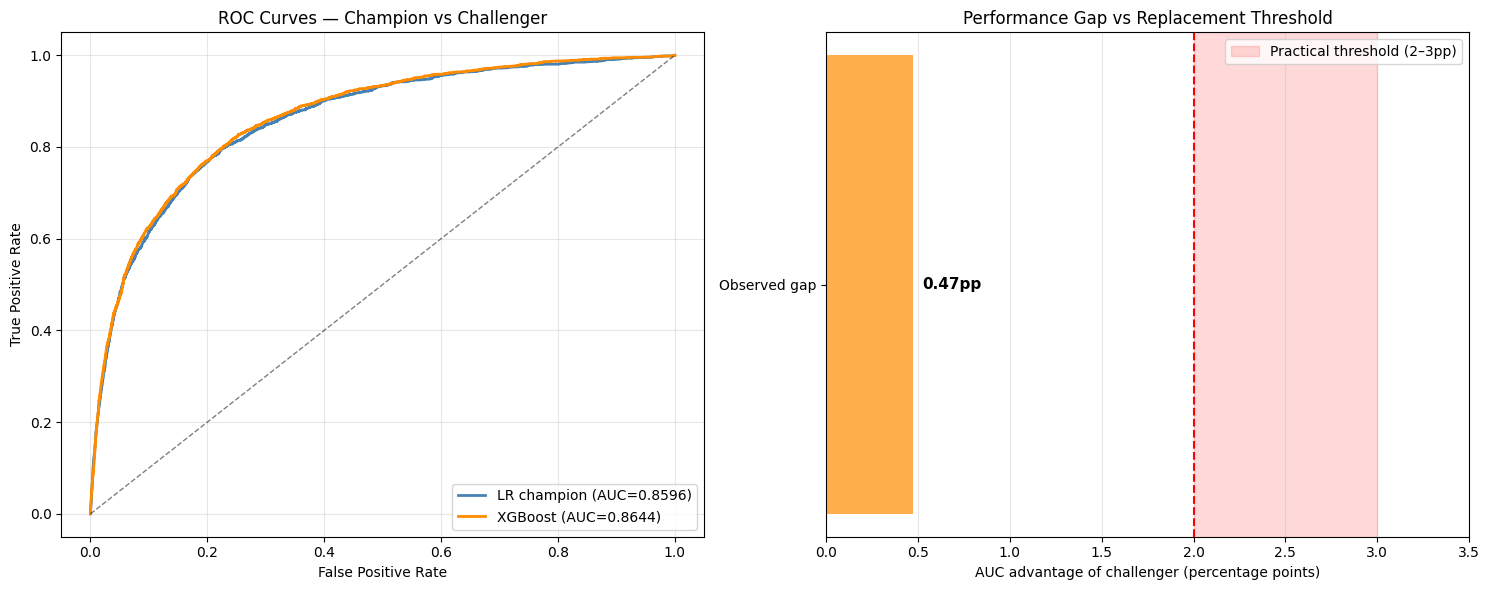

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: ROC curves overlaid
ax = axes[0]
fpr_lr,  tpr_lr,  _ = roc_curve(y_test_arr, p_lr_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_arr, p_xgb_test)
ax.plot(fpr_lr,  tpr_lr,  color='steelblue',  linewidth=2, label=f'LR champion (AUC={auc_lr:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='darkorange', linewidth=2, label=f'XGBoost (AUC={auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Champion vs Challenger')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Panel 2: AUC gap vs threshold
ax = axes[1]
observed_gap = (auc_xgb - auc_lr) * 100
threshold_low, threshold_high = 2.0, 3.0
ax.barh(['Observed gap'], [observed_gap], color='darkorange', alpha=0.7, height=0.4)
ax.axvspan(threshold_low, threshold_high, alpha=0.15, color='red',
           label='Practical threshold (2–3pp)')
ax.axvline(threshold_low, color='red', linestyle='--', linewidth=1.5)
ax.set_xlim(0, 3.5)
ax.set_xlabel('AUC advantage of challenger (percentage points)')
ax.set_title('Performance Gap vs Replacement Threshold')
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)
ax.text(observed_gap + 0.05, 0, f'{observed_gap:.2f}pp',
        va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/04_champion_challenger_decision.png', dpi=120, bbox_inches='tight')
plt.show()

## Champion Decision

### Evidence summary

DeLong's test: z = −6.02, p < 0.0001. The 0.47pp AUC gap is statistically significant 
beyond any doubt. The AUC correlation between the two models is 0.984, which is why 
DeLong detects so small a gap at six sigma — the variance of the paired difference 
(√0.063e-5 ≈ 0.0008) is roughly 30× smaller than the variance of either marginal AUC. 
A naive overlapping-CI check would have wrongly concluded "no difference"; the paired 
test is the only valid comparison for two models scored on the same observations.

| Dimension | Finding | Favors |
|---|---|---|
| Discrimination (AUC, Gini, KS) | XGBoost higher on all three; AUC gap +0.47pp | Challenger |
| Calibration (Brier, log-loss) | XGBoost marginally better, driven by tail fit | Challenger |
| Stability (train-test gap) | Both ≈0; no overfitting in either | Tie |
| Statistical significance (DeLong) | z=−6.02, p<0.0001 — significant | Challenger |
| Practical materiality (vs 2–3pp threshold) | 0.47pp gap, well below threshold | Champion retained |
| Interpretability | LR: native scorecard, signed coefficients | Champion |
| Regulatory acceptance (Basel IRB) | LR: decades of precedent; XGB: needs explainability infrastructure | Champion |
| Auditability | LR: reproducible from coefficient table | Champion |

### Decision

**The logistic regression scorecard is retained as champion.**

The challenger is genuinely and uniformly stronger on performance — it wins discrimination, 
calibration, and tail fit — and the AUC gap is statistically significant at six sigma. 
Critically, the challenger is also equally stable, so the decision rests on no overfitting 
weakness in XGBoost. The decision rests instead on materiality and fitness for purpose: a 
0.47pp AUC gain, however statistically certain, falls well below the 2–3pp threshold at 
which the industry trades interpretability for discrimination. Against that immaterial gain 
stand the qualitative pillars where LR is decisively preferred — native interpretability via 
signed WoE coefficients, the direct scorecard-points mapping, established Basel IRB 
acceptance, full auditability from a coefficient table, and a lighter validation and 
monitoring burden.

This is a fit-for-purpose decision in the SR 11-7 sense. The statistically superior model is 
deliberately not selected, because its marginal, immaterial performance gain does not justify 
the model-risk and operational costs of opacity. The DeLong result is documented precisely to 
show that the decision was made with full knowledge that the gap is real — not because the 
challenger failed to beat the champion, but because beating it by 0.47pp is not enough.

### Handoff

The champion (calibrated LR) proceeds to Notebook 05 (IFRS 9 ECL) and Notebook 06 (Basel IRB 
capital) as the production PD engine. The challenger artifact (`xgb_challenger.pkl`) is 
retained as a documented benchmark and is re-fit in Notebook 07 for SHAP-based explainability — 
both to cross-check the champion's feature behavior and to demonstrate the explainability 
infrastructure that adopting the challenger would have required.

## 7. Segment-Level Performance Stability

The aggregate test AUC of 0.86 is a population-weighted average. It can mask segments where the model performs materially worse — and those segments still receive PD estimates that drive IFRS 9 staging and Basel capital. SR 11-7 requires demonstrating that a model is adequate across the subpopulations to which it is applied, not merely on average.

We partition the test set along three economically meaningful dimensions and compute discrimination within each segment:

1. **Age bands** — younger borrowers typically have thinner credit files and different default dynamics; a model trained on a population skewed older may rank them poorly.
2. **Income tiers** — the relationship between income and default is non-linear and segment-dependent; high earners default for different reasons than low earners.
3. **Delinquency history** — borrowers with prior delinquencies are a distinct risk population; the model must rank-order within this group, not just separate it from clean files.

**Methodological caveat.** Within-segment AUC requires both classes present, with enough defaulters for a stable estimate. We report segment size and default count alongside each AUC. A segment with very few defaulters yields a noisy AUC that should be interpreted with caution — we flag these explicitly rather than presenting them as equally reliable.

**Important note on the segmenting variables.** We segment on the *raw* feature values (age in years, income in currency, delinquency counts), not the WoE-transformed values used for modeling. The raw values define the economically interpretable segments; the model still scores using WoE features. We therefore reload the cleaned (pre-WoE) data from Notebook 01 to define segments.

In [18]:
# Load the cleaned (pre-WoE) test features to define economically interpretable segments.
# These align row-for-row with X_test_woe because both derive from the same split.
X_test_clean = pd.read_csv('../data/X_test_clean.csv')

# Verify alignment: same number of rows, same order
assert len(X_test_clean) == len(X_test_woe) == len(y_test_arr), "Row count mismatch"
print(f"Segmenting frame loaded: {X_test_clean.shape}")
print(f"Columns available for segmenting: {list(X_test_clean.columns)}\n")

# Build a working frame: raw segmenting variables + champion PD + outcome
seg = pd.DataFrame({
    'age': X_test_clean['age'].values,
    'MonthlyIncome': X_test_clean['MonthlyIncome'].values,
    'NumberOfTime30-59DaysPastDueNotWorse': X_test_clean['NumberOfTime30-59DaysPastDueNotWorse'].values,
    'pd_lr': p_lr_test,
    'pd_xgb': p_xgb_test,
    'y_true': y_test_arr,
})

print("Working segmentation frame head:")
print(seg.head().to_string(index=False))

Segmenting frame loaded: (30000, 11)
Columns available for segmenting: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'Ever90DaysPastDue', 'Ever60_89DaysPastDue', 'Income_missing', 'DebtRatio_valid']

Working segmentation frame head:
 age  MonthlyIncome  NumberOfTime30-59DaysPastDueNotWorse    pd_lr   pd_xgb  y_true
  66       8.551788                                     0 0.009172 0.008245       0
  78       7.741099                                     0 0.029453 0.019313       0
  59       9.290445                                     0 0.011225 0.007092       0
  59       9.200391                                     0 0.014136 0.010437       0
  67       8.691315                                     0 0.009920 0.009718       0


In [19]:
def segment_auc(df, segment_col, score_col='pd_lr', y_col='y_true',
                bins=None, labels=None, min_defaults=30):
    """
    Compute AUC within each segment of a partitioning variable.

    bins: either an int (quantile bins via qcut) or a list of edges (cut).
    Reports segment size, default count, default rate, and AUC.
    Flags segments with fewer than min_defaults as low-reliability.
    """
    d = df.copy()

    if isinstance(bins, int):
        d['segment'] = pd.qcut(d[segment_col], q=bins, duplicates='drop')
    elif bins is not None:
        d['segment'] = pd.cut(d[segment_col], bins=bins, labels=labels)
    else:
        d['segment'] = d[segment_col]   # categorical / discrete already

    rows = []
    for seg_val, g in d.groupby('segment', observed=True):
        n = len(g)
        n_def = int(g[y_col].sum())
        n_nondef = n - n_def
        if n_def > 0 and n_nondef > 0:
            seg_auc = roc_auc_score(g[y_col], g[score_col])
        else:
            seg_auc = np.nan   # AUC undefined without both classes
        rows.append({
            'segment': str(seg_val),
            'n': n,
            'defaults': n_def,
            'default_rate': n_def / n,
            'AUC': seg_auc,
            'reliable': n_def >= min_defaults,
        })

    out = pd.DataFrame(rows)
    out['default_rate'] = (out['default_rate'] * 100).round(2)
    out['AUC'] = out['AUC'].round(4)
    return out

# --- Segment 1: Age bands (economically meaningful edges) ---
age_bins = [0, 30, 40, 50, 60, 200]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']
age_seg = segment_auc(seg, 'age', bins=age_bins, labels=age_labels)
print("Segment AUC by age band (LR champion):\n")
print(age_seg.to_string(index=False))

# --- Segment 2: Income tiers (quintiles) ---
income_seg = segment_auc(seg, 'MonthlyIncome', bins=5)
print("\n\nSegment AUC by income quintile (LR champion):\n")
print(income_seg.to_string(index=False))

# --- Segment 3: Delinquency history ---
seg['delinq_group'] = np.where(
    seg['NumberOfTime30-59DaysPastDueNotWorse'] == 0,
    'No 30-59 delinquency',
    'Has 30-59 delinquency'
)
delinq_seg = segment_auc(seg, 'delinq_group')
print("\n\nSegment AUC by delinquency history (LR champion):\n")
print(delinq_seg.to_string(index=False))

Segment AUC by age band (LR champion):

segment    n  defaults  default_rate    AUC  reliable
  18-30 2124       273         12.85 0.8292      True
  31-40 4832       480          9.93 0.8332      True
  41-50 7102       599          8.43 0.8411      True
  51-60 6916       407          5.88 0.8490      True
    60+ 9026       246          2.73 0.8424      True


Segment AUC by income quintile (LR champion):

       segment     n  defaults  default_rate    AUC  reliable
(-0.001, 8.16]  6000       562          9.37 0.8432      True
 (8.16, 8.594] 11895       806          6.78 0.8687      True
(8.594, 8.598]   106         6          5.66 0.6817     False
(8.598, 9.018]  6002       367          6.11 0.8522      True
(9.018, 14.26]  5997       264          4.40 0.8480      True


Segment AUC by delinquency history (LR champion):

              segment     n  defaults  default_rate    AUC  reliable
Has 30-59 delinquency  4776      1023         21.42 0.7802      True
 No 30-59 delinquency 25

In [20]:
# For the most important segmentation (age), compare champion and challenger
# to confirm the 0.47pp gap is not concentrated in one segment.
age_seg_lr = segment_auc(seg, 'age', score_col='pd_lr',
                         bins=age_bins, labels=age_labels)
age_seg_xgb = segment_auc(seg, 'age', score_col='pd_xgb',
                          bins=age_bins, labels=age_labels)

age_compare = age_seg_lr[['segment', 'n', 'defaults', 'AUC']].copy()
age_compare = age_compare.rename(columns={'AUC': 'AUC_LR'})
age_compare['AUC_XGB'] = age_seg_xgb['AUC'].values
age_compare['gap_pp'] = ((age_compare['AUC_XGB'] - age_compare['AUC_LR']) * 100).round(2)

print("Champion vs challenger AUC by age band:\n")
print(age_compare.to_string(index=False))
print(f"\nAggregate AUC — LR: {auc_lr:.4f}, XGB: {auc_xgb:.4f}, gap: {(auc_xgb-auc_lr)*100:.2f}pp")

Champion vs challenger AUC by age band:

segment    n  defaults  AUC_LR  AUC_XGB  gap_pp
  18-30 2124       273  0.8292   0.8329    0.37
  31-40 4832       480  0.8332   0.8387    0.55
  41-50 7102       599  0.8411   0.8445    0.34
  51-60 6916       407  0.8490   0.8527    0.37
    60+ 9026       246  0.8424   0.8597    1.73

Aggregate AUC — LR: 0.8596, XGB: 0.8644, gap: 0.47pp


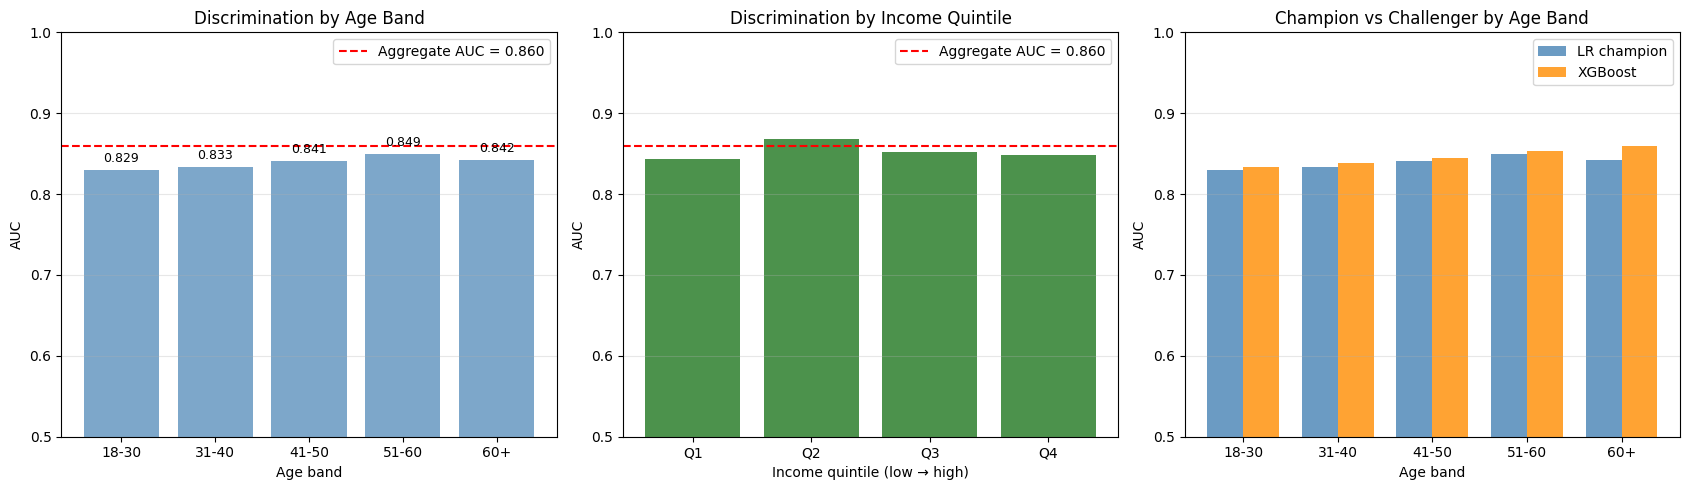

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: AUC by age band
ax = axes[0]
reliable = age_seg[age_seg['reliable']]
ax.bar(reliable['segment'], reliable['AUC'], color='steelblue', alpha=0.7)
ax.axhline(auc_lr, color='red', linestyle='--', linewidth=1.5,
           label=f'Aggregate AUC = {auc_lr:.3f}')
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Age band')
ax.set_ylabel('AUC')
ax.set_title('Discrimination by Age Band')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (_, r) in enumerate(reliable.iterrows()):
    ax.text(i, r['AUC'] + 0.01, f"{r['AUC']:.3f}", ha='center', fontsize=9)

# Panel 2: AUC by income quintile
ax = axes[1]
reliable_inc = income_seg[income_seg['reliable']].reset_index(drop=True)
ax.bar(range(len(reliable_inc)), reliable_inc['AUC'], color='darkgreen', alpha=0.7)
ax.axhline(auc_lr, color='red', linestyle='--', linewidth=1.5,
           label=f'Aggregate AUC = {auc_lr:.3f}')
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Income quintile (low → high)')
ax.set_ylabel('AUC')
ax.set_title('Discrimination by Income Quintile')
ax.set_xticks(range(len(reliable_inc)))
ax.set_xticklabels([f'Q{i+1}' for i in range(len(reliable_inc))])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Panel 3: champion vs challenger by age
ax = axes[2]
x = np.arange(len(age_compare))
width = 0.38
ax.bar(x - width/2, age_compare['AUC_LR'],  width, label='LR champion', color='steelblue', alpha=0.8)
ax.bar(x + width/2, age_compare['AUC_XGB'], width, label='XGBoost', color='darkorange', alpha=0.8)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Age band')
ax.set_ylabel('AUC')
ax.set_title('Champion vs Challenger by Age Band')
ax.set_xticks(x)
ax.set_xticklabels(age_compare['segment'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_segment_stability.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the segment stability block.**

**Age.** All five bands fall in a tight 0.829–0.849 range, every one well above the 
behavioral-model floor (~0.70). The youngest band (18-30), the most likely a priori to 
underperform on thin files, holds at 0.829 with 273 defaults. Within-band AUC sits below 
the 0.860 aggregate in every band — the expected conditioning effect, since age (IV 0.25) 
is itself a strong feature and partitioning on it removes the discrimination it contributes. 
No age-related model weakness.

**Income.** Performance is flat across reliable quintiles (0.843–0.869), with no monotonic 
income dependence. The quintiles are defined on log-imputed income (Notebook 01 scale): 
the edge 8.16 ≈ $3,500/month, 9.018 ≈ $8,250/month. One degenerate bin (n=106, AUC 0.68, 
flagged unreliable) is the log-median imputation pile-up from Notebook 01 — every 
income-missing row was imputed to the same value, creating a point mass that qcut isolated. 
This is a segmentation artifact, not a model defect, and the reliability flag correctly 
excludes it.

**Delinquency history.** Within the prior-delinquency group, AUC is 0.780 — the lowest 
reliable segment, and correctly so. Conditioning on "already delinquent" removes the easy 
clean-vs-delinquent separation and leaves the genuinely hard problem of ranking cure-vs-roll 
within a uniformly elevated-risk pool (21.4% default rate vs 3.9% for clean files). An AUC 
of 0.78 on that sub-problem is strong. This segment is also the most consequential: it holds 
1,023 of 2,005 test defaults — over half the defaulters in 16% of the population — so its 
0.78 carries disproportionate provisioning weight. Adequate, but the segment to monitor most 
closely.

**Champion vs challenger by age.** The 0.47pp aggregate gap is NOT uniform. It is 
0.34–0.55pp in bands up to 60, then jumps to 1.73pp in the 60+ band (LR 0.842, XGB 0.860). 
XGBoost's non-linear form captures interaction structure in older-borrower default behavior 
that the main-effects linear model misses. The decision holds — 60+ is the lowest-default 
segment (2.73%, 246 defaults), so the localized gain moves few provisioning dollars — but 
this is documented as a known limitation and a monitoring trigger: if the 60+ segment grows 
materially in the production book, the challenger advantage in that segment should be 
re-evaluated.

**Conclusion.** Discrimination is stable across all economically meaningful segments. No 
reliable segment falls below acceptability. The two genuine findings — the harder (but 
adequate) delinquency sub-problem and the localized 60+ challenger advantage — are documented 
as monitoring considerations rather than blocking issues. The champion is fit for purpose 
across the population to which it will be applied.

## 8. Key Finding and Handoff

### Central question, answered

> *Is our logistic regression scorecard discriminating, calibrated, and stable enough to serve as the PD engine for IFRS 9 provisioning and Basel IRB capital — and does a gradient-boosted challenger justify replacing it?*

**Yes on all three counts, and no to replacement.** The calibrated logistic regression scorecard discriminates strongly, is well-calibrated for absolute PD use, and is stable across every economically meaningful segment. A gradient-boosted challenger is statistically significantly better but by an immaterial margin, and the interpretable model is retained on fit-for-purpose grounds.

### Evidence base

**Discrimination (Sections 2–3).** Test AUC 0.8596, Gini 0.7192, KS 0.5716 — all above strong-discrimination benchmarks. Bootstrap 95% confidence intervals place every lower bound comfortably above its threshold (AUC lower bound 0.8508 vs 0.80 benchmark). No overfitting: the train-test gap is effectively zero on all metrics.

**Calibration (Section 4).** Mean absolute calibration gap of 0.72pp across deciles, monotonic predicted-vs-observed alignment, and a Brier reliability term of 0.0002 — calibration error 54× smaller than the discrimination contribution. The Hosmer-Lemeshow test rejects (p<0.0001), but this is the documented large-sample artifact: at n=30,000 the test detects statistically significant deviations of fractions of a percentage point that are economically immaterial. The decile table and bootstrap-banded calibration curve are the instruments of record. The Notebook 03 prior correction is confirmed sound.

**Champion-challenger (Sections 5–6).** XGBoost outperforms on every metric (AUC +0.47pp, Gini +0.95pp, KS +0.24pp, Brier −0.0010, log-loss −0.0039) and is equally stable. DeLong's test confirms the AUC gap is statistically significant at six sigma (z=−6.02, p<0.0001), enabled by the 0.984 AUC correlation that shrinks the paired-difference variance ~30×. The gap is nonetheless well below the 2–3pp materiality threshold for replacing an interpretable regulatory model. The champion is retained on the qualitative pillars: native interpretability, scorecard-points mapping, Basel IRB acceptance, auditability, and lighter validation burden.

**Segment stability (Section 7).** Discrimination is stable across age (0.829–0.849), income (flat across quintiles), and delinquency history. The prior-delinquency segment (AUC 0.780) is the hardest and most consequential sub-problem — over half the defaulters in 16% of the population — and remains adequate. The challenger's advantage is localized to the 60+ segment (1.73pp vs 0.47pp aggregate), documented as a monitoring trigger rather than a blocking issue.

### SR 11-7 conceptual soundness statement

The model satisfies the validation-stage requirements:

1. **Discrimination is established with quantified uncertainty** — point estimates plus bootstrap confidence intervals, not bare metrics.
2. **Calibration is validated for absolute PD use** — formal goodness-of-fit testing, with correct interpretation of large-sample test behavior.
3. **The champion decision is documented and defensible** — the superior model was identified, its superiority quantified and tested, and its rejection justified on materiality and fitness-for-purpose grounds. The decision was made with full knowledge that the gap is statistically real.
4. **Segment adequacy is demonstrated** — performance holds across the subpopulations to which the model is applied, with known limitations explicitly flagged for monitoring.

### Champion specification (handoff to Notebooks 05 and 06)

| Property | Value |
|---|---|
| Model | Logistic regression, L1 penalty, C=0.01 |
| Features | 9 WoE-transformed (NumberOfDependents, Income_missing dropped by L1) |
| Calibration | Bayes log-odds prior correction (offset −2.636) |
| Test AUC / Gini / KS | 0.8596 / 0.7192 / 0.5716 |
| Mean predicted PD | 7.06% (test) vs 6.68% true |
| Artifact | `../models/lr_champion.pkl` |
| Predictions | `../data/predictions_test.csv`, `predictions_train.csv` |

### What the downstream notebooks receive

**Notebook 05 — IFRS 9 ECL.** Consumes the calibrated PD as the point-in-time 12-month PD. The calibration validation here certifies that PD is fit for the PD × LGD × EAD provisioning calculation. Known consideration: the highest-risk decile carries a small (~4pp) conservative bias, favorable for provisioning. Notebook 05 will address SICR thresholds, three-stage staging, and the construction of lifetime PD from the 12-month PIT estimate.

**Notebook 06 — Basel IRB capital.** Consumes the same PD, transformed toward a through-the-cycle estimate and floored at the regulatory minimum (0.03%), as input to the ASRF risk-weight formula. Notebook 06 will contrast the PIT calibration validated here with the TTC requirement of the IRB framework.

**Notebook 07 — SHAP explainability.** Consumes the retained challenger artifact (`xgb_challenger.pkl`) to demonstrate the explainability infrastructure an opaque model requires, and to cross-check the champion's feature behavior against the tree ensemble's learned structure — including investigating the source of the localized 60+ performance gap identified in Section 7.

### Closing note

The substantive output of this notebook is not the AUC of 0.86. It is the documented, defensible decision to deploy a slightly-less-performant interpretable model over a statistically-superior black box, made with full quantification of what that choice costs. That decision — and the evidence trail supporting it — is the deliverable that distinguishes a regulatory model development exercise from a Kaggle leaderboard.